In [9]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# === 数据 & 模型准备（复用上节） ===
np.random.seed(42)
data = np.sin(np.linspace(0, 8 * np.pi, 500)) + 0.1 * np.random.randn(500)

X, y = [], []
for i in range(len(data) - 20):
    X.append(data[i:i + 20])
    y.append(data[i + 20])
X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)

X_test = torch.FloatTensor(X[split:]).unsqueeze(-1)
y_test = torch.FloatTensor(y[split:])

In [10]:
class LSTMPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, 2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)

In [11]:
model = LSTMPredictor()
model.load_state_dict(torch.load("lstm_predictor.pt"))

<All keys matched successfully>

In [12]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()

y_true = y_test.numpy()

In [13]:
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))

In [14]:
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

MSE: 0.017399
MAE: 0.105399


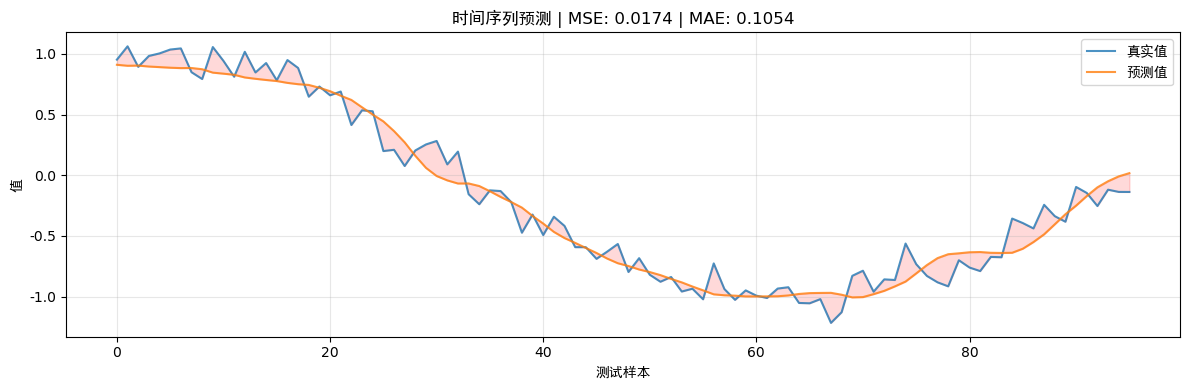

In [15]:
plt.rcParams["font.family"] = ["DejaVu Sans", "SimHei", "Microsoft YaHei"]
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 4))
plt.plot(y_true, label="真实值", linewidth=1.5, alpha=0.8)
plt.plot(y_pred, label="预测值", linewidth=1.5, alpha=0.8)

plt.fill_between(range(len(y_true)), y_true, y_pred, alpha=0.15, color="red")
plt.title(f"时间序列预测 | MSE: {mse:.4f} | MAE: {mae:.4f}")
plt.xlabel("测试样本")
plt.ylabel("值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=100)

plt.show()